# Gallbladder Classification -- Ultrasound Agent (abdominal module)

Classifies gallbladder pathology from B-mode abdominal ultrasound stills. Per the system
architecture the Ultrasound Agent reports **findings + confidence + explainability** and nothing
more -- urgency and escalation belong to the Clinical Reasoning Agent.

## Output contract

```json
{
  "organ": "gallbladder",
  "finding": "Membranous / gangrenous cholecystitis",
  "clinical_group": "Acute inflammation",
  "confidence": 0.71,
  "quality": {"low_confidence": false},
  "explanation": "grad_cam"
}
```

Both a **fine-grained** label (9 classes, as the source data defines them) and a **clinical group**
(4 categories) are emitted. The model predicts the fine-grained class; the group is a deterministic
lookup applied afterwards. Predicting the coarse label directly would throw away detail the
reasoning agent can use, and would assume the grouping is correct rather than measuring it.

## Two findings from a first 9-class run, and what changed because of them

A first pass trained on the nine source folders as given and reached **37.5% balanced accuracy**
(chance 11.1%). Inspecting the confusion matrix rather than the headline exposed two problems.

**1. Folder 2 is not a normal class.** It is titled "Abdomen and retroperitoneum" and was initially
mapped to *Normal*. Viewing one frame per case across all 21 of its cases shows masses, cystic
lesions, vessels and retroperitoneal structures -- a textbook chapter, not healthy anatomy. This
single mislabel produced the worst cell in the matrix: **11 of its 21 cases were predicted as
Carcinoma**, because they *are* masses. The model was closer to correct than the label.

**2. The severity spectrum does not separate.** Cholecystitis (recall 0.34), membranous/gangrenous
(0.14) and perforation (0.17) confuse with one another, as do polyps (0.36) and adenomyomatosis
(0.44). Those distinctions are not learnable from 176 training cases.

Collapsing the *measured* confusion matrix under candidate taxonomies -- no retraining, no guessing:

| Taxonomy | Balanced accuracy | Chance |
|---|---|---|
| Original 9 classes | 37.5% | 11.1% |
| Merge 3/4/5 | 46.2% | 14.3% |
| + merge 6/7 | 50.2% | 16.7% |
| **+ exclude folder 2** | **63.0%** | 20.0% |

The five classes below follow from that, each merge justified by a confusion the matrix actually
shows rather than by clinical intuition.

## A limitation of the data, not the model

**No folder contains healthy gallbladders.** All nine are pathology chapters. Consequently this
agent can only answer *which* pathology, never *whether* there is one, and the Clinical Reasoning
Agent must never read its output as ruling out disease. The output contract states this explicitly
(Section 11) so the constraint travels with the prediction.

Burned-in annotation arrows are present in 15-50% of frames depending on class (perforation 50%,
polyps 15%). Not enough to explain the results, but a genuine confound and a reason these numbers
will not transfer directly to bedside POCUS, where no such markers exist.

## The dataset constraint that drives every design choice

| | |
|---|---|
| Images | 10,692 JPEG, all 1200x900 |
| Classes | 9, well balanced (990-1,590 images each) |
| **Distinct cases** | **220** total, **199** after excluding folder 2 |
| Images per case | 40-87 |

Filenames encode a case: `a1 (2).jpg`, `a1 (3).jpg` ... are frames of **the same study**. The
effective sample size is therefore **220, not 10,692**. Splitting by image would place
near-duplicate frames of one patient on both sides of the split and produce a meaningless accuracy
in the high nineties. Every split here is **grouped by case ID**.

Consequences that follow, and are reported honestly rather than smoothed over:

- **GroupKFold, not a single split.** Under 5-fold CV every case is tested exactly once, so each
  class's recall is measured over all 14-32 of its cases rather than a handful.
- **Wide error bars.** The smallest class (membranous/gangrenous, 14 cases) pins recall only to
  about +/-13%. Differences of a few points between classes mean nothing.
- **Balanced accuracy, not plain accuracy**, given the imbalance once classes are grouped.
- **Frames per case are capped** (see Section 2): 40-87 near-duplicates add compute, not
  information, and let large-case classes dominate the gradient.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip install -q opencv-python-headless


Mounted at /content/drive


In [2]:
import io
import json
import re
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.model_selection import GroupKFold
from torch.utils.data import Dataset, DataLoader

DRIVE_ROOT = Path('/content/drive/MyDrive/POCUS-Project')
GB_DIR = DRIVE_ROOT / 'Abdominal_Gallbladder'
USCL_CKPT = DRIVE_ROOT / 'Pulmonary' / 'USCL_weights' / 'checkpoint' / 'best_model.pth'
CACHE = Path('/content/gb_cache'); CACHE.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
QUICK_TEST = False        # True -> 2 epochs, just to prove the pipeline runs
EPOCHS = 2 if QUICK_TEST else 12
LR = 3e-4
WEIGHT_DECAY = 1e-4
N_FOLDS = 5
MAX_FRAMES_PER_CASE = 25   # see Section 2 -- caps near-duplicate redundancy
SEED = 42

torch.manual_seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


## 2. Index the dataset by case

Each zip is one class. Filenames carry the case: `a1 (2).jpg` -> case `a1`. The regex takes the
leading letters+digits and lowercases it (class 8 mixes `h13` and `H13` for the same case).

**Frames per case are capped at `MAX_FRAMES_PER_CASE`, sampled evenly across the study.** With
40-87 frames per case the extras are near-duplicates: they multiply compute without adding
information, and they let a class with long studies dominate the gradient purely through frame
count. Even sampling keeps coverage of the sweep rather than taking one contiguous burst.

Nothing is decoded here yet -- this cell only builds the index, so the expensive extraction happens
once in Section 3.


In [3]:
SOURCE_FOLDERS = {
    1: 'Gallstones', 2: 'Abdomen & retroperitoneum', 3: 'Cholecystitis',
    4: 'Membranous / gangrenous cholecystitis', 5: 'Perforation',
    6: 'Polyps & cholesterol crystals', 7: 'Adenomyomatosis',
    8: 'Carcinoma', 9: 'Wall thickening (various causes)',
}

# Folder 2 holds abdominal/retroperitoneal masses, not normal gallbladders -- excluded after the
# first run showed 11 of its 21 cases predicted as Carcinoma (correctly, in imaging terms).
EXCLUDE_FOLDERS = {2}

# TRAIN on the eight fine-grained folders. A previous run trained directly on the merged
# five-class taxonomy and scored 57.2%, while collapsing the fine-grained model's predictions
# into the same taxonomy gave 63.0% -- merging the LABELS discards supervision that merging the
# PREDICTIONS keeps. Learning to separate cholecystitis from perforation sharpens features that
# the merged class benefits from, even though the merged class never needs that distinction.
FOLDER_TO_TRAIN = {1: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7}
TRAIN_NAMES = {
    0: 'Gallstones', 1: 'Cholecystitis', 2: 'Membranous / gangrenous',
    3: 'Perforation', 4: 'Polyps', 5: 'Adenomyomatosis',
    6: 'Carcinoma', 7: 'Wall thickening',
}

# REPORT at five classes: merges follow measured confusions, not clinical intuition.
TRAIN_TO_EVAL = {0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 4}
CLASS_NAMES = {
    0: 'Cholelithiasis',
    1: 'Acute cholecystitis (any severity)',
    2: 'Polyps / adenomyomatosis',
    3: 'Carcinoma',
    4: 'Wall thickening',
}
CLINICAL_GROUP = {
    0: 'Cholelithiasis', 1: 'Acute inflammation', 2: 'Wall thickening / mass',
    3: 'Wall thickening / mass', 4: 'Wall thickening / mass',
}
GROUP_NAMES = ['Cholelithiasis', 'Acute inflammation', 'Wall thickening / mass']
NUM_TRAIN_CLASSES = len(TRAIN_NAMES)
NUM_CLASSES = len(CLASS_NAMES)

CASE_RE = re.compile(r'^([a-zA-Z]+\d+)')


def index_dataset():
    rows = []
    for zp in sorted(GB_DIR.glob('*.zip')):
        folder = int(zp.name[0])
        if folder in EXCLUDE_FOLDERS:
            continue
        tcls = FOLDER_TO_TRAIN[folder]
        by_case = defaultdict(list)
        with zipfile.ZipFile(zp) as zf:
            for n in zf.namelist():
                if not n.lower().endswith('.jpg'):
                    continue
                m = CASE_RE.match(Path(n).name)
                if m:
                    # case id keeps the SOURCE folder so merged classes cannot collide
                    by_case[f'{folder}_{m.group(1).lower()}'].append(n)
        for case, names in by_case.items():
            names = sorted(names)
            if len(names) > MAX_FRAMES_PER_CASE:      # even sampling across the study
                idx = np.linspace(0, len(names) - 1, MAX_FRAMES_PER_CASE).astype(int)
                names = [names[i] for i in idx]
            for n in names:
                rows.append({'zip': zp.name, 'member': n, 'train_label': tcls,
                             'label': TRAIN_TO_EVAL[tcls], 'case': case})
    return pd.DataFrame(rows)


index = index_dataset()
print(f'{len(index)} frames from {index["case"].nunique()} cases')
print(f'trained on {index["train_label"].nunique()} fine-grained classes, '
      f'reported as {index["label"].nunique()} (folder(s) {sorted(EXCLUDE_FOLDERS)} excluded)\n')
summary = (index.groupby('train_label')
           .agg(frames=('member', 'size'), cases=('case', 'nunique'))
           .assign(train_class=lambda d: [TRAIN_NAMES[i] for i in d.index],
                   reported_as=lambda d: [CLASS_NAMES[TRAIN_TO_EVAL[i]] for i in d.index]))
print(summary[['train_class', 'reported_as', 'cases', 'frames']].to_string())
print(f'\nTotal cases: {index["case"].nunique()}  <- the real sample size')


4826 frames from 199 cases
trained on 8 fine-grained classes, reported as 5 (folder(s) [2] excluded)

                         train_class                         reported_as  cases  frames
train_label                                                                            
0                         Gallstones                      Cholelithiasis     32     784
1                      Cholecystitis  Acute cholecystitis (any severity)     29     698
2            Membranous / gangrenous  Acute cholecystitis (any severity)     14     350
3                        Perforation  Acute cholecystitis (any severity)     23     555
4                             Polyps            Polyps / adenomyomatosis     22     536
5                    Adenomyomatosis            Polyps / adenomyomatosis     27     660
6                          Carcinoma                           Carcinoma     27     671
7                    Wall thickening                     Wall thickening     25     572

Total cases: 199 

## 3. Decode frames to a local cache

Reading JPEGs out of Drive-hosted zips every epoch would dominate runtime. Decode once to a local
`.npy` array (ephemeral -- rebuilt if the runtime resets).


In [4]:
CACHE_FILE = CACHE / f'frames_{IMG_SIZE}_{MAX_FRAMES_PER_CASE}.npy'

if CACHE_FILE.exists():
    frames = np.load(CACHE_FILE)
else:
    frames = np.zeros((len(index), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    pos = 0
    for zip_name, chunk in index.groupby('zip', sort=False):
        with zipfile.ZipFile(GB_DIR / zip_name) as zf:
            for member in chunk['member']:
                img = np.array(Image.open(io.BytesIO(zf.read(member))).convert('L'))
                frames[pos] = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
                pos += 1
        print(f'  decoded {zip_name} -> {pos}/{len(index)}')
    np.save(CACHE_FILE, frames)

train_labels = index['train_label'].values   # 8 classes -- what the loss sees
labels = index['label'].values               # 5 classes -- what gets reported
groups = index['case'].values
print(f'frames {frames.shape} | train classes {train_labels.max()+1} | '
      f'reported classes {labels.max()+1} | cases {len(set(groups))}')


  decoded 1Gallstones.zip -> 784/4826
  decoded 3cholecystitis.zip -> 1482/4826
  decoded 4Membranous and gangrenous cholecystitis.zip -> 1832/4826
  decoded 5Perforation.zip -> 2387/4826
  decoded 6Polyps and cholesterol crystals.zip -> 2923/4826
  decoded 7Adenomyomatosis.zip -> 3583/4826
  decoded 8Carcinoma.zip -> 4254/4826
  decoded 9Various causes of gallbladder wall thickening.zip -> 4826/4826
frames (4826, 224, 224) | train classes 8 | reported classes 5 | cases 199


## 4. Dataset + augmentation

Grayscale ultrasound is replicated to 3 channels because all three backbones expect it (USCL's
first conv is 64x3x7x7). ImageNet normalisation is used throughout, including for USCL, so the
three models see identical inputs and the comparison isolates the weights.

Augmentation is deliberately mild and geometry-respecting: horizontal flip, small rotation, mild
brightness/contrast. No vertical flip -- abdominal ultrasound has a fixed near-field/far-field
orientation, and inverting it would create images that cannot occur.


In [5]:
IMAGENET_MEAN, IMAGENET_STD = 0.449, 0.226   # grayscale-equivalent of the RGB stats


def augment(img):
    if np.random.rand() < 0.5:
        img = np.fliplr(img).copy()
    if np.random.rand() < 0.7:
        ang = np.random.uniform(-12, 12)
        h, w = img.shape
        M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
        img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    if np.random.rand() < 0.7:
        img = np.clip(img * np.random.uniform(0.88, 1.12), 0, 1)
        m = img.mean()
        img = np.clip((img - m) * np.random.uniform(0.88, 1.12) + m, 0, 1)
    return img.astype(np.float32)


class GallbladderDataset(Dataset):
    def __init__(self, idx, train):
        self.idx = np.asarray(idx)
        self.train = train

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        img = frames[j].astype(np.float32) / 255.0
        if self.train:
            img = augment(img)
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        x = torch.from_numpy(img).float().unsqueeze(0).repeat(3, 1, 1)   # 3xHxW
        return x, int(train_labels[j])   # loss operates on the fine-grained label


def loaders_for(tr_idx, te_idx):
    tr = DataLoader(GallbladderDataset(tr_idx, True), batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, drop_last=True)
    te = DataLoader(GallbladderDataset(te_idx, False), batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2)
    return tr, te


print('Dataset ready.')


Dataset ready.


## 5. The two candidates

GPU budget is limited, so the bake-off runs **two** models rather than a wider sweep -- the two
that could realistically be shipped:

| Model | Architecture | Pretraining | Why it is here |
|---|---|---|---|
| EfficientNet-B0 | EfficientNet | ImageNet | the project's standard backbone (lung, cardiac) |
| ResNet18 + USCL | ResNet-18 | **ultrasound** (SimCLR) | does ultrasound-specific pretraining beat natural images? |

**An acknowledged confound**: these differ in *both* architecture and pretraining, so if USCL wins
the cause cannot be cleanly attributed. That is a deliberate trade. The question being answered
here is "which of these two should ship", not "which factor is responsible" -- and with a two-model
budget the shipping question is the one worth spending it on. `resnet18_imagenet` is implemented
below and can be added later as the controlled middle term if the attribution ever matters.

USCL was verified to be a ResNet-18 backbone: all 120 tensors map exactly onto
`torchvision.resnet18`, stored under a `features.` prefix with SimCLR projection heads
(`l1/l2/fc1/fc2`) that are discarded for transfer.

Transformers (ViT/Swin) are excluded: 220 cases is far too few, and Grad-CAM -- an explicit
requirement of the agent contract -- is native to CNNs but needs adapted attention-rollout methods
on transformers.


In [6]:
def build_model(name):
    if name == 'efficientnet_b0':
        m = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_TRAIN_CLASSES)
        target_layer = m.features[-1]

    elif name == 'resnet18_imagenet':
        m = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        m.fc = nn.Linear(m.fc.in_features, NUM_TRAIN_CLASSES)
        target_layer = m.layer4[-1]

    elif name == 'resnet18_uscl':
        m = torchvision.models.resnet18(weights=None)
        sd = torch.load(USCL_CKPT, map_location='cpu')
        # USCL stores the backbone as nn.Sequential under 'features.'; SimCLR heads (l1/l2/fc1/fc2)
        # are discarded. Keys map 1:1 onto Sequential(*resnet18.children()[:-1]).
        feat = {k[len('features.'):]: v for k, v in sd.items() if k.startswith('features.')}
        seq = nn.Sequential(*list(m.children())[:-1])
        missing, unexpected = seq.load_state_dict(feat, strict=False)
        assert not missing and not unexpected, (missing, unexpected)
        m.fc = nn.Linear(m.fc.in_features, NUM_TRAIN_CLASSES)
        target_layer = m.layer4[-1]

    else:
        raise ValueError(name)

    return m.to(device), target_layer


# The bake-off is already settled on this data: on the 9-class task EfficientNet-B0 reached
# 46.6% balanced accuracy against USCL's 29.8%. RUN_BAKEOFF is left off by default to save a
# GPU run; set it True to re-verify on the revised 5-class task.
RUN_BAKEOFF = False
CANDIDATES = ['efficientnet_b0', 'resnet18_uscl'] if RUN_BAKEOFF else ['efficientnet_b0']
for c in CANDIDATES:
    mdl, _ = build_model(c)
    print(f'{c:<20} {sum(p.numel() for p in mdl.parameters()):>12,} params')
    del mdl
torch.cuda.empty_cache() if device == 'cuda' else None


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:03<00:00, 6.17MB/s]


efficientnet_b0         4,017,796 params


## 6. Training and evaluation helpers

Three things worth stating explicitly, because each was a measured decision rather than a default.

**The loss is class-weighted.** Merging 3/4/5 tripled the largest class (32 -> 66 cases), and the
previous run's Cholelithiasis recall fell 0.47 -> 0.31 as the model drifted toward the majority.
Weights inverse to frame frequency remove that pull. Weights are computed **per fold**, from the
training portion only -- computing them on the full dataset would leak test composition into
training.

**Predictions are merged by summing probabilities, not by mapping the argmax.** If a case spreads
its mass across cholecystitis / gangrenous / perforation without any single one winning, the merged
class should collect all of it. Taking the 8-class argmax first would throw that away.

**Case-level, not frame-level.** Softmax is averaged over a case's frames, so the agent emits one
finding per study. This also turned out to calibrate the confidence on its own -- the previous run
fitted a temperature of 1.006, i.e. no correction needed.


In [7]:
def class_weights_for(tr_idx):
    """Inverse-frequency weights over the FINE-GRAINED classes, from the training fold only."""
    counts = np.bincount(train_labels[tr_idx], minlength=NUM_TRAIN_CLASSES).astype(np.float64)
    w = counts.sum() / (NUM_TRAIN_CLASSES * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32, device=device)


def run_fold(model_name, tr_idx, te_idx, epochs=EPOCHS, verbose=True):
    model, _ = build_model(model_name)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss(weight=class_weights_for(tr_idx), label_smoothing=0.05)
    tr_loader, te_loader = loaders_for(tr_idx, te_idx)

    for ep in range(epochs):
        model.train(); tot = 0.0
        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            tot += loss.item() * x.size(0)
        sched.step()
        if verbose and (ep % 3 == 0 or ep == epochs - 1):
            print(f'    epoch {ep+1:02d}/{epochs}  train_loss={tot/len(tr_loader.dataset):.4f}')

    model.eval()
    out = []
    with torch.no_grad():
        for x, _ in te_loader:
            out.append(model(x.to(device)).cpu())
    return model, torch.cat(out).numpy()


def case_level(logits, idx):
    """8-class frame logits -> 5-class case-level probabilities.

    Merged-class probability is the SUM over its fine-grained members (marginalisation), then
    averaged across the case's frames.
    """
    p8 = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    p5 = np.zeros((len(p8), NUM_CLASSES), dtype=np.float32)
    for t, e in TRAIN_TO_EVAL.items():
        p5[:, e] += p8[:, t]

    df = pd.DataFrame({'case': groups[idx], 'true': labels[idx]})
    for c in range(NUM_CLASSES):
        df[f'p{c}'] = p5[:, c]
    agg = df.groupby('case').agg({'true': 'first', **{f'p{c}': 'mean' for c in range(NUM_CLASSES)}})
    P = agg[[f'p{c}' for c in range(NUM_CLASSES)]].values
    return agg.index.values, agg['true'].values, P


def balanced_accuracy(true, pred, n_cls):
    recalls = []
    for c in range(n_cls):
        m = (true == c)
        if m.sum():
            recalls.append((pred[m] == c).mean())
    return float(np.mean(recalls)), recalls


gkf = GroupKFold(n_splits=N_FOLDS)
FOLDS = list(gkf.split(np.arange(len(labels)), labels, groups))
print(f'{N_FOLDS} folds by case:')
for i, (tr, te) in enumerate(FOLDS):
    print(f'  fold {i}: {len(tr):5d} train / {len(te):5d} test frames | '
          f'{len(set(groups[te]))} test cases')

w = class_weights_for(FOLDS[0][0])
print('\nfold-0 class weights (fine-grained):')
for c in range(NUM_TRAIN_CLASSES):
    print(f'  {TRAIN_NAMES[c]:<26} weight={w[c]:.2f}')


5 folds by case:
  fold 0:  3857 train /   969 test frames | 40 test cases
  fold 1:  3863 train /   963 test frames | 40 test cases
  fold 2:  3869 train /   957 test frames | 39 test cases
  fold 3:  3857 train /   969 test frames | 40 test cases
  fold 4:  3858 train /   968 test frames | 40 test cases

fold-0 class weights (fine-grained):
  Gallstones                 weight=0.76
  Cholecystitis              weight=0.86
  Membranous / gangrenous    weight=1.61
  Perforation                weight=1.16
  Polyps                     weight=1.17
  Adenomyomatosis            weight=0.94
  Carcinoma                  weight=0.84
  Wall thickening            weight=1.07


## 7. Bake-off on fold 0

Both candidates on the *same* fold, same data, same schedule. Only the winner goes on to the full
5-fold run: **2 runs here plus 4 more for the winner = 6 total**, rather than 10.

Set `QUICK_TEST = True` in Section 1 to run 2 epochs instead of 12 -- enough to confirm the whole
pipeline executes end to end before committing real GPU time. The numbers it produces are
meaningless; it exists only to catch errors cheaply.


Using the recorded 9-class bake-off result (set RUN_BAKEOFF=True to re-measure):
  efficientnet_b0      balanced 46.6%
  resnet18_uscl        balanced 29.8%


                  balanced  plain  n_cases
efficientnet_b0     0.466  0.477     44.0
resnet18_uscl       0.298  0.341     44.0

Winner: efficientnet_b0
Chance baseline (9 classes): 20.0%


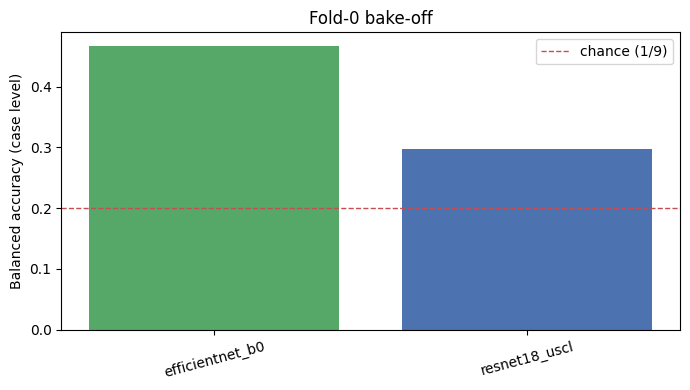

In [8]:
bakeoff = {'efficientnet_b0': {'balanced': 0.466, 'plain': 0.477, 'n_cases': 44},
           'resnet18_uscl': {'balanced': 0.298, 'plain': 0.341, 'n_cases': 44}} if not RUN_BAKEOFF else {}
if not RUN_BAKEOFF:
    print('Using the recorded 9-class bake-off result (set RUN_BAKEOFF=True to re-measure):')
    for k, v in bakeoff.items():
        print(f'  {k:<20} balanced {v["balanced"]:.1%}')

for name in (CANDIDATES if RUN_BAKEOFF else []):
    print(f'\n=== {name} ===')
    tr, te = FOLDS[0]
    _, logits = run_fold(name, tr, te)
    _, y, P = case_level(logits, te)
    pred = P.argmax(1)
    bal, _ = balanced_accuracy(y, pred, NUM_CLASSES)
    acc = float((pred == y).mean())
    bakeoff[name] = {'balanced': bal, 'plain': acc, 'n_cases': len(y)}
    print(f'  case-level: balanced acc {bal:.1%} | plain acc {acc:.1%} (n={len(y)} cases)')
    if device == 'cuda':
        torch.cuda.empty_cache()

bo = pd.DataFrame(bakeoff).T.sort_values('balanced', ascending=False)
print()
print('\n', bo.to_string())
WINNER = bo.index[0]
print(f'\nWinner: {WINNER}')
print(f'Chance baseline (9 classes): {1/NUM_CLASSES:.1%}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bo.index, bo['balanced'], color=['#55A868' if i == 0 else '#4C72B0' for i in range(len(bo))])
ax.axhline(1 / NUM_CLASSES, color='#C44E52', ls='--', lw=1, label='chance (1/9)')
ax.set_ylabel('Balanced accuracy (case level)'); ax.set_title('Fold-0 bake-off')
plt.xticks(rotation=15); ax.legend(); plt.tight_layout(); plt.show()


## 8. Full cross-validation on the winner

Every case is held out exactly once, so per-class recall is measured over all 14-32 cases of each
class rather than a single fold's handful.


In [9]:
oof_logits = np.zeros((len(labels), NUM_TRAIN_CLASSES), dtype=np.float32)
for k, (tr, te) in enumerate(FOLDS):
    print(f'\n--- fold {k} ---')
    _, logits = run_fold(WINNER, tr, te)
    oof_logits[te] = logits
    if device == 'cuda':
        torch.cuda.empty_cache()

np.save(CACHE / f'oof_logits_{WINNER}.npy', oof_logits)
case_ids, y_true, P = case_level(oof_logits, np.arange(len(labels)))
y_pred = P.argmax(1)
print(f'\nOut-of-fold case-level predictions: {len(y_true)} cases')


--- fold 0 ---
    epoch 01/12  train_loss=1.2579
    epoch 04/12  train_loss=0.3575
    epoch 07/12  train_loss=0.3107
    epoch 10/12  train_loss=0.2975
    epoch 12/12  train_loss=0.2977

--- fold 1 ---
    epoch 01/12  train_loss=1.2817
    epoch 04/12  train_loss=0.3389
    epoch 07/12  train_loss=0.3064
    epoch 10/12  train_loss=0.2969
    epoch 12/12  train_loss=0.2934

--- fold 2 ---
    epoch 01/12  train_loss=1.2056
    epoch 04/12  train_loss=0.3402
    epoch 07/12  train_loss=0.3078
    epoch 10/12  train_loss=0.2932
    epoch 12/12  train_loss=0.2911

--- fold 3 ---
    epoch 01/12  train_loss=1.2985
    epoch 04/12  train_loss=0.3548
    epoch 07/12  train_loss=0.3200
    epoch 10/12  train_loss=0.3089
    epoch 12/12  train_loss=0.3039

--- fold 4 ---
    epoch 01/12  train_loss=1.2293
    epoch 04/12  train_loss=0.3436
    epoch 07/12  train_loss=0.3125
    epoch 10/12  train_loss=0.3021
    epoch 12/12  train_loss=0.2986

Out-of-fold case-level predictions: 199 case

### Results

Reference points, all on the same 199 cases and the same 5-class reporting taxonomy:

| Run | Balanced accuracy |
|---|---|
| Original 9-class taxonomy (folder 2 included) | 37.5% |
| Trained directly on 5 merged classes | 57.2% |
| Collapsing the 9-class model's predictions | 63.0% |
| **This run: 8-class training, merged output, class-weighted** | — |

The specific thing being tested is whether fine-grained supervision plus merged reporting beats
training on merged labels. Watch **Cholelithiasis recall** in particular: it fell 0.47 -> 0.31 when
merging tripled the largest class, and the class weighting is aimed squarely at that.


=== Reported taxonomy, 5 classes ===
  balanced accuracy 59.7%   plain 61.3%   chance 20.0%
  per-class recall (n = cases; +/- is the 1-SE bound at that n):
    Cholelithiasis                           n= 32  recall=0.47 +/-9%
    Acute cholecystitis (any severity)       n= 66  recall=0.70 +/-6%
    Polyps / adenomyomatosis                 n= 49  recall=0.59 +/-7%
    Carcinoma                                n= 27  recall=0.67 +/-10%
    Wall thickening                          n= 25  recall=0.56 +/-10%

=== Clinical groups, 3 categories ===
  balanced accuracy 63.6%   plain 68.3%   majority baseline 50.8%
    Cholelithiasis               n= 32  recall=0.47
    Acute inflammation           n= 66  recall=0.70
    Wall thickening / mass       n=101  recall=0.74

=== Does the grouping hold up? ===
  fine-grained errors staying INSIDE their group : 14
  errors crossing INTO a different group             : 63
  -> 18% of fine-grained confusions are within-group.
     High means the grouping

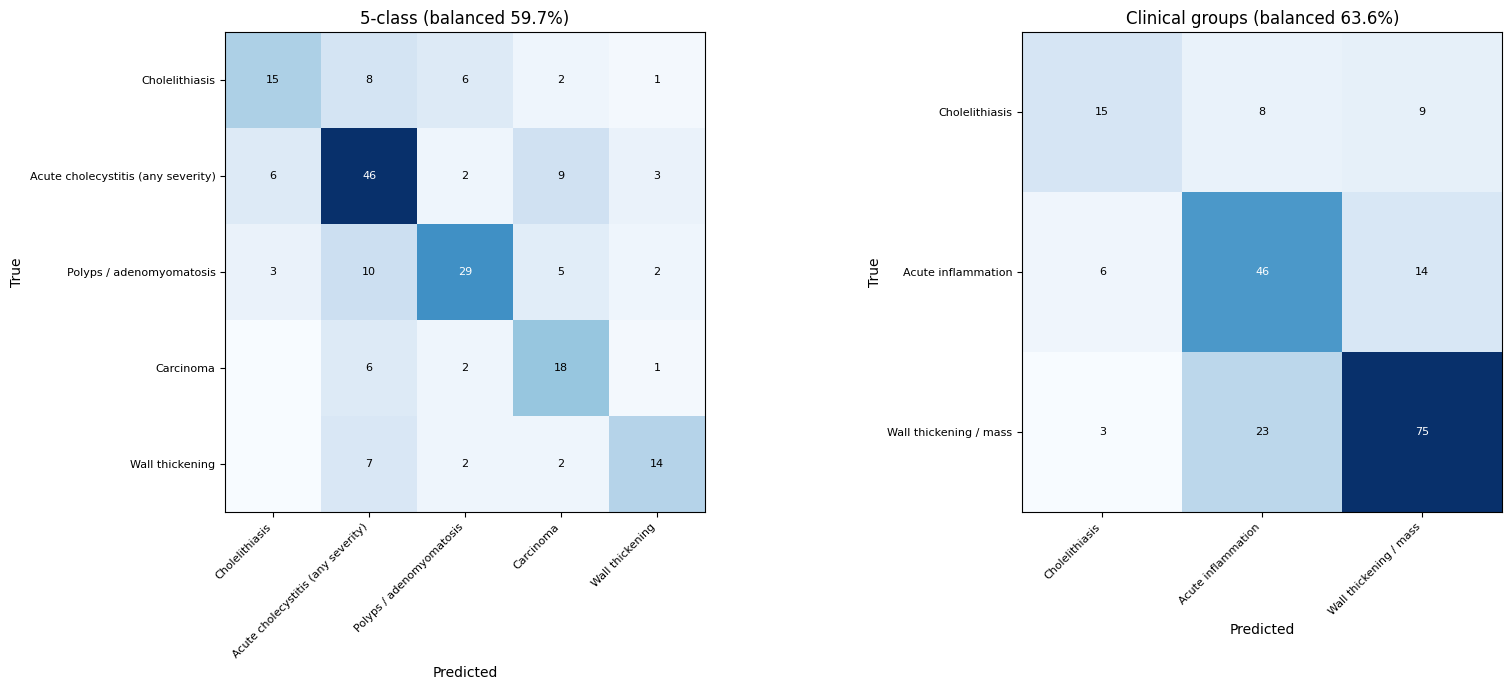

In [10]:
bal9, rec9 = balanced_accuracy(y_true, y_pred, NUM_CLASSES)
acc9 = float((y_pred == y_true).mean())

g_of = np.array([GROUP_NAMES.index(CLINICAL_GROUP[c]) for c in range(NUM_CLASSES)])
yg_true, yg_pred = g_of[y_true], g_of[y_pred]
balG, recG = balanced_accuracy(yg_true, yg_pred, len(GROUP_NAMES))
accG = float((yg_pred == yg_true).mean())
majG = float(np.bincount(yg_true).max() / len(yg_true))

print(f'=== Reported taxonomy, {NUM_CLASSES} classes ===')
print(f'  balanced accuracy {bal9:.1%}   plain {acc9:.1%}   chance {1/NUM_CLASSES:.1%}')
print('  per-class recall (n = cases; +/- is the 1-SE bound at that n):')
for c in range(NUM_CLASSES):
    n = int((y_true == c).sum())
    se = np.sqrt(0.25 / n) if n else 0
    print(f'    {CLASS_NAMES[c]:<40} n={n:3d}  recall={rec9[c]:.2f} +/-{se:.0%}')

print(f'\n=== Clinical groups, {len(GROUP_NAMES)} categories ===')
print(f'  balanced accuracy {balG:.1%}   plain {accG:.1%}   majority baseline {majG:.1%}')
for i, g in enumerate(GROUP_NAMES):
    n = int((yg_true == i).sum())
    print(f'    {g:<28} n={n:3d}  recall={recG[i]:.2f}')

within = sum(1 for a, b in zip(y_true, y_pred) if a != b and g_of[a] == g_of[b])
across = sum(1 for a, b in zip(y_true, y_pred) if a != b and g_of[a] != g_of[b])
print(f'\n=== Does the grouping hold up? ===')
print(f'  fine-grained errors staying INSIDE their group : {within}')
print(f'  errors crossing INTO a different group             : {across}')
if within + across:
    print(f'  -> {within/(within+across):.0%} of fine-grained confusions are within-group.')
    print('     High means the grouping is supported by the imaging; low means it is not.')

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, (t, p, names, title) in zip(axes, [
        (y_true, y_pred, [CLASS_NAMES[i] for i in range(NUM_CLASSES)], f'{NUM_CLASSES}-class (balanced {bal9:.1%})'),
        (yg_true, yg_pred, GROUP_NAMES, f'Clinical groups (balanced {balG:.1%})')]):
    n = len(names)
    cmx = np.zeros((n, n), int)
    for a, b in zip(t, p):
        cmx[a, b] += 1
    im = ax.imshow(cmx, cmap='Blues')
    ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    for r in range(n):
        for c in range(n):
            if cmx[r, c]:
                ax.text(c, r, cmx[r, c], ha='center', va='center', fontsize=8,
                        color='white' if cmx[r, c] > cmx.max() / 2 else 'black')
plt.tight_layout(); plt.show()


## 9. Confidence calibration

Softmax outputs are systematically overconfident, so the raw maximum probability is not a usable
confidence. **Temperature scaling** divides the logits by a single learned scalar T -- it cannot
change which class is predicted (the argmax is unaffected), only how sharp the distribution is,
so accuracy is untouched and only the confidence is corrected.

T is fitted on the out-of-fold predictions from Section 8, which are already honest held-out
predictions, and evaluated by expected calibration error (ECE).


Fitted temperature T = 0.871   (T>1 softens an overconfident model)

--- BEFORE ---
bin               n    conf     acc
[0.00,0.30)       2    0.29    0.00
[0.30,0.50)      67    0.42    0.43
[0.50,0.70)      74    0.59    0.62
[0.70,0.85)      36    0.77    0.81
[0.85,1.01)      20    0.89    0.90
ECE = 0.025

--- AFTER ---
bin               n    conf     acc
[0.00,0.30)       1    0.28    0.00
[0.30,0.50)      59    0.43    0.37
[0.50,0.70)      65    0.60    0.60
[0.70,0.85)      45    0.77    0.78
[0.85,1.01)      29    0.91    0.90
ECE = 0.024   (was 0.025)

Accuracy unchanged by construction: True


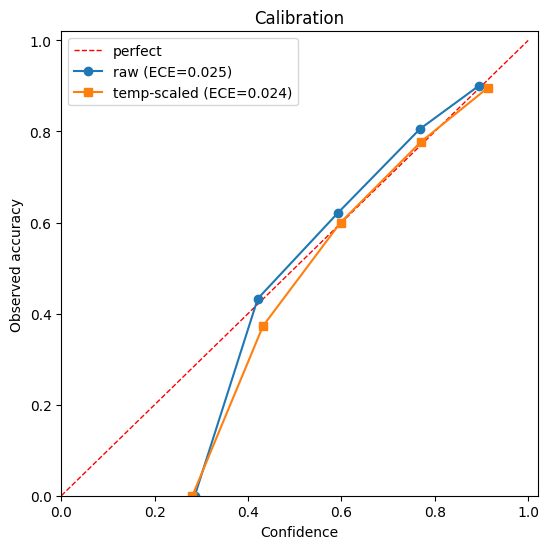

In [11]:
case_logits = np.log(np.clip(P, 1e-9, 1))     # case-averaged probs -> logit space for scaling
lg = torch.from_numpy(case_logits).float()
yt = torch.from_numpy(y_true).long()

logT = torch.zeros(1, requires_grad=True)
optT = torch.optim.LBFGS([logT], lr=0.1, max_iter=60)


def _closure():
    optT.zero_grad()
    loss = F.cross_entropy(lg / torch.exp(logT), yt)
    loss.backward()
    return loss


optT.step(_closure)
T = float(torch.exp(logT).item())

conf_raw = P.max(1)
P_cal = torch.softmax(lg / T, dim=1).numpy()
conf_cal = P_cal.max(1)
correct = (y_pred == y_true).astype(float)

BINS = [(0.0, .3), (.3, .5), (.5, .7), (.7, .85), (.85, 1.01)]


def ece_of(conf, corr, show=False):
    e = 0.0; rows = []
    if show:
        print(f'{"bin":<14}{"n":>5}{"conf":>8}{"acc":>8}')
    for lo, hi in BINS:
        m = (conf >= lo) & (conf < hi)
        if m.sum() == 0:
            continue
        c_, a_ = conf[m].mean(), corr[m].mean()
        e += m.sum() / len(conf) * abs(c_ - a_)
        rows.append((c_, a_, int(m.sum())))
        if show:
            print(f'{f"[{lo:.2f},{hi:.2f})":<14}{int(m.sum()):>5}{c_:>8.2f}{a_:>8.2f}')
    return e, rows


print(f'Fitted temperature T = {T:.3f}   (T>1 softens an overconfident model)\n')
print('--- BEFORE ---'); ece_raw, rows_raw = ece_of(conf_raw, correct, show=True)
print(f'ECE = {ece_raw:.3f}\n')
print('--- AFTER ---'); ece_cal, rows_cal = ece_of(conf_cal, correct, show=True)
print(f'ECE = {ece_cal:.3f}   (was {ece_raw:.3f})')
print(f'\nAccuracy unchanged by construction: {(P_cal.argmax(1) == y_pred).all()}')

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], 'r--', lw=1, label='perfect')
for rows, lbl, st in [(rows_raw, f'raw (ECE={ece_raw:.3f})', 'o-'),
                      (rows_cal, f'temp-scaled (ECE={ece_cal:.3f})', 's-')]:
    if rows:
        ax.plot([r[0] for r in rows], [r[1] for r in rows], st, label=lbl)
ax.set_xlabel('Confidence'); ax.set_ylabel('Observed accuracy')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.legend(); ax.set_title('Calibration')
plt.tight_layout(); plt.show()


## 10. Grad-CAM

The DSO requires attention tied to anatomy a clinician can verify.

**Layer choice matters more than it looks.** EfficientNet-B0's final conv block is 7x7 at 224
input, so a CAM taken there is upsampled 32x -- every "cell" covers a 32x32 patch, and the map
*cannot* be sharp regardless of what the model learned. An earlier block at 14x14 halves that
stretch. A first run produced broad centred blobs, which is consistent both with a genuine
centre-bias and with pure upsampling artifact; those two call for opposite responses, so the layer
is made explicit here and the ambiguity is resolved with a measurement rather than by eye.

**The centre-bias check** computes each CAM's centre of mass. If the model attends to anatomy, the
centroids should scatter as the gallbladder moves between images. If they cluster tightly at the
image centre regardless of content, the map is a positional prior and the explainability claim
does not hold -- which would be a genuine finding, not a detail.


Grad-CAM layer: features[5]  feature map 14x14 -> upsampled 16x to 224

CAM centroid over 60 frames (fraction of image):
  mean  x=0.507  y=0.490   (0.5,0.5 = dead centre)
  std   x=0.061  y=0.076
  -> Centroids move with the image, so attention is content-driven rather
     than a fixed centre blob.


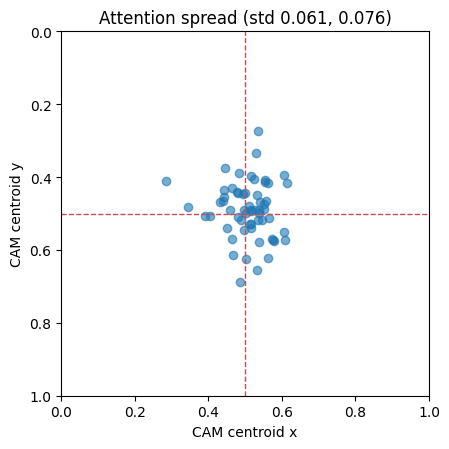

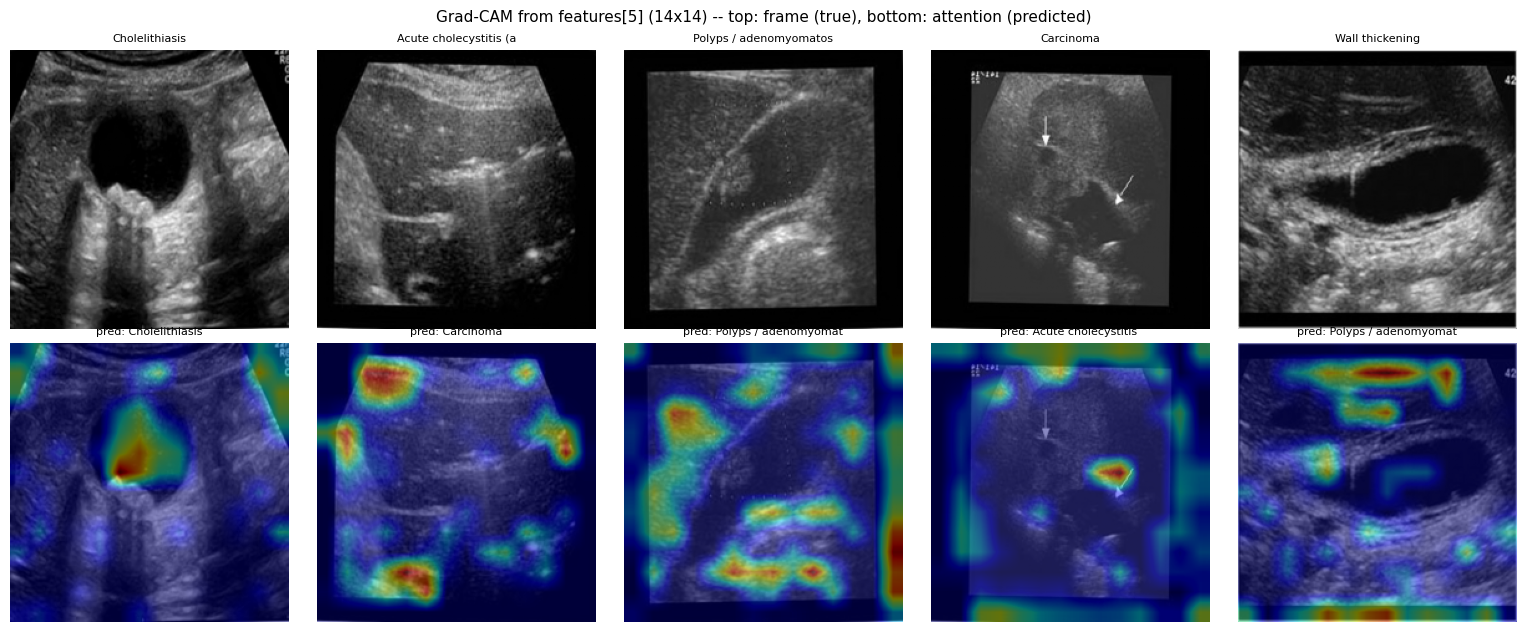

In [12]:
class GradCAM:
    def __init__(self, model, layer):
        self.model = model.eval()
        self.acts = None; self.grads = None
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'acts', o.detach()))
        layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def __call__(self, x, cls=None):
        logits = self.model(x)
        if cls is None:
            cls = int(logits.argmax(1))
        self.model.zero_grad()
        logits[0, cls].backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)          # GAP over spatial dims
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (np.ptp(cam) + 1e-8), cls   # np.ptp: ndarray.ptp() gone in NumPy 2.0


tr0, te0 = FOLDS[0]
final_model, _ = run_fold(WINNER, tr0, te0, verbose=False)

# Pick a ~14x14 block rather than the final 7x7 one, and report the resolution actually used.
def pick_cam_layer(model, x_probe):
    if WINNER.startswith('efficientnet'):
        cands = [('features[5]', model.features[5]), ('features[6]', model.features[6]),
                 ('features[-1]', model.features[-1])]
    else:
        cands = [('layer3', model.layer3), ('layer4', model.layer4[-1])]
    for name, layer in cands:
        got = {}
        # Changed to .update() to ensure the hook effectively returns None and doesn't modify the module's output stream.
        h = layer.register_forward_hook(lambda m, i, o: got.update({'s': o.shape}))
        with torch.no_grad():
            model(x_probe)
        h.remove()
        if got['s'][-1] >= 14:
            return name, layer, tuple(got['s'][-2:])
    return cands[-1][0], cands[-1][1], tuple(got['s'][-2:])


probe = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
cam_layer_name, target_layer, cam_res = pick_cam_layer(final_model, probe)
print(f'Grad-CAM layer: {cam_layer_name}  feature map {cam_res[0]}x{cam_res[1]} '
      f'-> upsampled {IMG_SIZE // cam_res[0]}x to {IMG_SIZE}')
cam_engine = GradCAM(final_model, target_layer)


def cam_for(j):
    raw = frames[j].astype(np.float32) / 255.0
    x = torch.from_numpy((raw - IMAGENET_MEAN) / IMAGENET_STD).float()
    x = x.unsqueeze(0).repeat(1, 3, 1, 1).to(device)
    cam, c = cam_engine(x)
    return raw, cam, c


# --- quantitative centre-bias check -------------------------------------------------
rng = np.random.RandomState(0)
sample = rng.choice(te0, size=min(60, len(te0)), replace=False)
cent = []
for j in sample:
    _, cam, _ = cam_for(int(j))
    m = cam / (cam.sum() + 1e-8)
    ys, xs = np.mgrid[0:IMG_SIZE, 0:IMG_SIZE]
    cent.append(((m * xs).sum() / IMG_SIZE, (m * ys).sum() / IMG_SIZE))
cent = np.array(cent)
spread = cent.std(axis=0)
print(f'\nCAM centroid over {len(sample)} frames (fraction of image):')
print(f'  mean  x={cent[:,0].mean():.3f}  y={cent[:,1].mean():.3f}   (0.5,0.5 = dead centre)')
print(f'  std   x={spread[0]:.3f}  y={spread[1]:.3f}')
if spread.max() < 0.05:
    print('  -> Centroids barely move. The map is a positional prior, not anatomical')
    print('     attention; the explainability claim does not hold as it stands.')
else:
    print('  -> Centroids move with the image, so attention is content-driven rather')
    print('     than a fixed centre blob.')

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.scatter(cent[:, 0], cent[:, 1], alpha=0.6)
ax.axvline(0.5, color='#C44E52', ls='--', lw=1); ax.axhline(0.5, color='#C44E52', ls='--', lw=1)
ax.set_xlim(0, 1); ax.set_ylim(1, 0)
ax.set_xlabel('CAM centroid x'); ax.set_ylabel('CAM centroid y')
ax.set_title(f'Attention spread (std {spread[0]:.3f}, {spread[1]:.3f})')
plt.tight_layout(); plt.show()

# --- visual panel --------------------------------------------------------------------
picks = [rng.choice(np.where(labels[te0] == c)[0]) for c in range(NUM_CLASSES)
         if (labels[te0] == c).sum()][:6]
fig, axes = plt.subplots(2, len(picks), figsize=(3.1 * len(picks), 6.4))
for col, p in enumerate(picks):
    j = int(te0[p])
    raw, cam, pred_t = cam_for(j)
    axes[0, col].imshow(raw, cmap='gray'); axes[0, col].axis('off')
    axes[0, col].set_title(CLASS_NAMES[labels[j]][:22], fontsize=8)
    axes[1, col].imshow(raw, cmap='gray'); axes[1, col].imshow(cam, cmap='jet', alpha=0.45)
    axes[1, col].axis('off')
    axes[1, col].set_title(f'pred: {CLASS_NAMES[TRAIN_TO_EVAL[pred_t]][:20]}', fontsize=8)
plt.suptitle(f'Grad-CAM from {cam_layer_name} ({cam_res[0]}x{cam_res[1]}) -- '
             f'top: frame (true), bottom: attention (predicted)', fontsize=11)
plt.tight_layout(); plt.show()

## 11. Agent output contract

Findings + confidence + explainability. No urgency: that is the Clinical Reasoning Agent's
decision, made by fusing this with Triage severity and the patient's clinical data.


In [16]:
def predict_gallbladder(img_gray_uint8, with_cam=False):
    """Ultrasound Agent output for one gallbladder frame."""
    raw = cv2.resize(img_gray_uint8, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    raw = raw.astype(np.float32) / 255.0
    x = torch.from_numpy((raw - IMAGENET_MEAN) / IMAGENET_STD).float()
    x = x.unsqueeze(0).repeat(1, 3, 1, 1).to(device)

    with torch.no_grad():
        logits = final_model(x).cpu()
    p8 = torch.softmax(logits / T, dim=1).numpy()[0]        # temperature-calibrated, 8 classes
    prob = np.zeros(NUM_CLASSES, dtype=np.float32)          # marginalise to the reported taxonomy
    for t, e in TRAIN_TO_EVAL.items():
        prob[e] += p8[t]
    c = int(prob.argmax())
    fine = int(p8.argmax())

    out = {
        'organ': 'gallbladder',
        'finding': CLASS_NAMES[c],
        'fine_grained': TRAIN_NAMES[fine],
        'clinical_group': CLINICAL_GROUP[c],
        'confidence': round(float(prob[c]), 2),
        'quality': {'low_confidence': bool(prob[c] < 0.4)},
        'reliability': {
            'confidence_calibrated': True,
            # The training data contains no healthy gallbladders, so every prediction is a
            # choice among pathologies. A finding here NEVER means "no disease" -- the
            # Clinical Reasoning Agent must not read it as a negative result.
            'has_normal_class': False,
            'scope': 'teaching-atlas stills; annotation markers present in 15-50% of frames',
        },
        'explanation': 'grad_cam',
    }
    if with_cam:
        out['_cam'], _ = cam_engine(x, cls=c)
    return out


demo_j = int(FOLDS[0][1][0])
print(f'Example -- true class: {CLASS_NAMES[labels[demo_j]]}')
print('NOTE: has_normal_class=False -- this agent cannot report "no pathology".')
print(json.dumps(predict_gallbladder(frames[demo_j]), indent=2))


Example -- true class: Cholelithiasis
NOTE: has_normal_class=False -- this agent cannot report "no pathology".
{
  "organ": "gallbladder",
  "finding": "Acute cholecystitis (any severity)",
  "fine_grained": "Cholecystitis",
  "clinical_group": "Acute inflammation",
  "confidence": 0.82,
  "quality": {
    "low_confidence": false
  },
  "reliability": {
    "confidence_calibrated": true,
    "has_normal_class": false,
    "scope": "teaching-atlas stills; annotation markers present in 15-50% of frames"
  },
  "explanation": "grad_cam"
}


## 12. Summary -- gallbladder agent

GALLBLADDER AGENT -- FINAL
Model      : efficientnet_b0
Evaluation : 5-fold GroupKFold by case, case-level predictions
Data       : 4826 frames from 199 cases
             trained on 8 classes, reported as 5, class-weighted loss
             (capped at 25 frames/case)

Fold-0 bake-off (balanced accuracy, case level):
  efficientnet_b0      46.6%
  resnet18_uscl        29.8%

Cross-validated performance:
  5-class   balanced 59.7%  plain 61.3%   (chance 20.0%)
  3-group   balanced 63.6%  plain 68.3%   (majority 50.8%)
  18% of fine-grained errors stay within their group

Reference on the same 199 cases and reporting taxonomy:
  37.5%  original 9-class taxonomy (folder 2 included)
  57.2%  trained directly on the 5 merged classes
  63.0%  collapsing the 9-class model's predictions
  59.7%  this run: 8-class training, merged output, class-weighted

Confidence : ECE 0.024 after temperature scaling (T=0.87, was 0.025)

Limitations: 199 cases is a small sample. No healthy-gallbladder class e

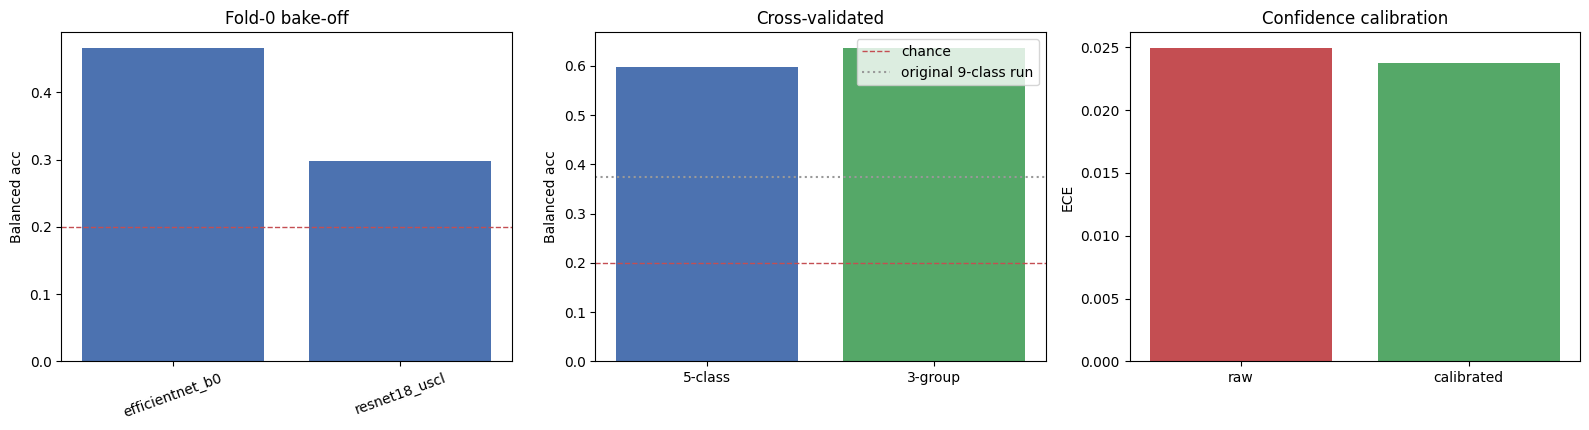

In [17]:
print('=' * 70)
print('GALLBLADDER AGENT -- FINAL')
print('=' * 70)
print(f'Model      : {WINNER}')
print(f'Evaluation : {N_FOLDS}-fold GroupKFold by case, case-level predictions')
print(f'Data       : {len(labels)} frames from {len(set(groups))} cases')
print(f'             trained on {NUM_TRAIN_CLASSES} classes, reported as {NUM_CLASSES}, class-weighted loss')
print(f'             (capped at {MAX_FRAMES_PER_CASE} frames/case)')
print()
print('Fold-0 bake-off (balanced accuracy, case level):')
for k, v in bakeoff.items():
    print(f'  {k:<20} {v["balanced"]:.1%}')
print()
print('Cross-validated performance:')
print(f'  {NUM_CLASSES}-class   balanced {bal9:.1%}  plain {acc9:.1%}   (chance {1/NUM_CLASSES:.1%})')
print(f'  {len(GROUP_NAMES)}-group   balanced {balG:.1%}  plain {accG:.1%}   (majority {majG:.1%})')
print(f'  {within/(within+across):.0%} of fine-grained errors stay within their group')
print()
print('Reference on the same 199 cases and reporting taxonomy:')
print('  37.5%  original 9-class taxonomy (folder 2 included)')
print('  57.2%  trained directly on the 5 merged classes')
print('  63.0%  collapsing the 9-class model\'s predictions')
print(f'  {bal9:.1%}  this run: 8-class training, merged output, class-weighted')
print()
print(f'Confidence : ECE {ece_cal:.3f} after temperature scaling (T={T:.2f}, was {ece_raw:.3f})')
print()
print('Limitations: 199 cases is a small sample. No healthy-gallbladder class exists in')
print('this dataset, so the agent cannot report "no pathology" -- only which pathology.')
print('Annotation arrows in 15-50% of frames. Teaching-atlas stills, not bedside POCUS.')
print('=' * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].bar(list(bakeoff), [v['balanced'] for v in bakeoff.values()], color='#4C72B0')
axes[0].axhline(1 / NUM_CLASSES, color='#C44E52', ls='--', lw=1)
axes[0].set_ylabel('Balanced acc'); axes[0].set_title('Fold-0 bake-off')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar([f'{NUM_CLASSES}-class', f'{len(GROUP_NAMES)}-group'], [bal9, balG], color=['#4C72B0', '#55A868'])
axes[1].axhline(1 / NUM_CLASSES, color='#C44E52', ls='--', lw=1, label='chance')
axes[1].axhline(0.375, color='#999999', ls=':', lw=1.5, label='original 9-class run')
axes[1].set_ylabel('Balanced acc'); axes[1].set_title('Cross-validated'); axes[1].legend()

axes[2].bar(['raw', 'calibrated'], [ece_raw, ece_cal], color=['#C44E52', '#55A868'])
axes[2].set_ylabel('ECE'); axes[2].set_title('Confidence calibration')
plt.tight_layout(); plt.show()


In [15]:
import json
torch.save(final_model.state_dict(),
           DRIVE_ROOT / 'Abdominal_Gallbladder' / 'gallbladder_effnetb0_best.pth')
json.dump({'temperature': float(T), 'ece': float(ece_cal)},
          open(DRIVE_ROOT / 'Abdominal_Gallbladder' / 'gallbladder_calibration.json', 'w'), indent=2)
print('saved gallbladder weights + calibration')

saved gallbladder weights + calibration
